# Exploring motor data
This script only estimates the effective mass of the motor shaft but also...
- analyzes the noisiness of the data
- tries different smoothing effects on positional data to extract acceleration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

In [3]:
# ---------------------------------------------------------------------------
# Motor shaft position constants (in µm)
# ---------------------------------------------------------------------------
MOTOR_MIN_UM = 106
MOTOR_MAX_UM = 223615
MOTOR_CENTER_UM = int((MOTOR_MAX_UM - MOTOR_MIN_UM) / 2 + MOTOR_MIN_UM)

## Functions

In [4]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
DATA_DIR = "mass_estimation_data_2026_03_06"


def load_trial_index(data_dir=DATA_DIR):
    """Load the trial index file and return a DataFrame of trial metadata."""
    index_path = os.path.join(data_dir, "trial_index.npz")
    idx = np.load(index_path, allow_pickle=True)
    df = pd.DataFrame({
        "trial_num": idx["trial_nums"],
        "force_commanded_mN": idx["forces_mN"],
        "iteration": idx["iterations"],
        "n_samples": idx["n_samples"],
        "filename": idx["filenames"],
    })
    return df


def load_trial(filename, data_dir=DATA_DIR):
    """Load a single trial .npz file and return a DataFrame."""
    path = os.path.join(data_dir, filename)
    data = np.load(path, allow_pickle=True)

    n = len(data["t_stream"])
    df = pd.DataFrame({
        "t_stream": data["t_stream"][:n],
        "t_accel": data["t_accel"][:n],
        "position_um": data["position_um"][:n],
        "force_mN": data["force_mN"][:n],
        "accel_mmpss": data["accel_mmpss"][:n],
    })
    # Make time relative to trial start
    t0 = df["t_stream"].iloc[0]
    df["t_stream_s"] = df["t_stream"] - t0
    df["t_accel_s"] = df["t_accel"] - t0
    df["force_commanded_mN"] = int(data["force_commanded_mN"])
    return df


def load_all_trials(data_dir=DATA_DIR):
    """Load every trial into a dict keyed by trial_num."""
    index = load_trial_index(data_dir)
    trials = {}
    for _, row in index.iterrows():
        tnum = row["trial_num"]
        trials[tnum] = load_trial(row["filename"], data_dir)
        trials[tnum]["trial_num"] = tnum
    return index, trials


In [5]:
# ---------------------------------------------------------------------------
# V2 data loaders (sinusoidal haptic procedure)
# ---------------------------------------------------------------------------
DATA_DIR_V2 = "mass_estimation_data_v2_2026_03_05"


def load_trial_index_v2(data_dir=DATA_DIR_V2):
    """Load the v2 trial index file and return a DataFrame of trial metadata."""
    index_path = os.path.join(data_dir, "trial_index.npz")
    idx = np.load(index_path, allow_pickle=True)
    df = pd.DataFrame({
        "trial_num": idx["trial_nums"],
        "n_samples": idx["n_samples"],
        "filename": idx["filenames"],
        "spring_strength": idx["spring_strengths"],
        "spring_center_um": idx["spring_centers_um"],
        "osc_max_force_mN": idx["osc_max_forces_mN"],
        "osc_frequency_hz": idx["osc_frequencies_hz"],
        "osc_duty_cycle": idx["osc_duty_cycles"],
    })
    return df


def load_trial_v2(filename, data_dir=DATA_DIR_V2):
    """Load a single v2 trial .npz file and return a DataFrame."""
    path = os.path.join(data_dir, filename)
    data = np.load(path, allow_pickle=True)

    n = len(data["t_stream"])
    df = pd.DataFrame({
        "t_stream": data["t_stream"][:n],
        "t_accel": data["t_accel"][:n],
        "position_um": data["position_um"][:n],
        "force_mN": data["force_mN"][:n],
        "accel_mmpss": data["accel_mmpss"][:n],
    })
    # Make time relative to trial start
    t0 = df["t_stream"].iloc[0]
    df["t_stream_s"] = df["t_stream"] - t0
    df["t_accel_s"] = df["t_accel"] - t0
    return df


def load_all_trials_v2(data_dir=DATA_DIR_V2):
    """Load every v2 trial into a dict keyed by trial_num."""
    index = load_trial_index_v2(data_dir)
    trials = {}
    for _, row in index.iterrows():
        tnum = row["trial_num"]
        trials[tnum] = load_trial_v2(row["filename"], data_dir)
        trials[tnum]["trial_num"] = tnum
    return index, trials

In [6]:
# ---------------------------------------------------------------------------
# Plotting functions for Procedure 1
# ---------------------------------------------------------------------------

def plot_single_trial(trial_df, title_suffix=""):
    """Plot position, force, and acceleration vs time for one trial."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(trial_df["t_stream_s"], trial_df["position_um"], "b-", linewidth=0.8)
    axes[0].set_ylabel("Position (µm)")
    axes[0].set_title(f"Trial Data {title_suffix}")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(trial_df["t_stream_s"], trial_df["force_mN"], "r-", linewidth=0.8)
    axes[1].set_ylabel("Force (mN)")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(trial_df["t_accel_s"], trial_df["accel_mmpss"], "g-", linewidth=0.8)
    axes[2].set_ylabel("Acceleration (mm/s²)")
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_by_trial_numbers(trials, trial_nums, field="position_um"):
    """Overlay a chosen field for selected trial numbers."""
    fig, ax = plt.subplots(figsize=(10, 5))
    for tnum in trial_nums:
        df = trials[tnum]
        t_col = "t_accel_s" if field == "accel_mmpss" else "t_stream_s"
        label = f"Trial {tnum} ({df['force_commanded_mN'].iloc[0]} mN)"
        ax.plot(df[t_col], df[field], linewidth=0.8, label=label)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(field)
    ax.set_title(f"{field} by trial")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_by_force(index, trials, force_mN, field="position_um"):
    """Overlay a chosen field for all trials at a given force level."""
    matching = index[index["force_commanded_mN"] == force_mN]
    trial_nums = matching["trial_num"].tolist()
    fig = plot_by_trial_numbers(trials, trial_nums, field=field)
    fig.axes[0].set_title(f"{field} — Force = {force_mN} mN")
    return fig


def plot_accel_vs_position(trials, trial_nums=None, force_mN=None):
    """Plot acceleration vs position (useful for mass estimation)."""
    fig, ax = plt.subplots(figsize=(10, 5))
    # Select trials
    if trial_nums is None:
        trial_nums = list(trials.keys())
    for tnum in trial_nums:
        df = trials[tnum]
        if force_mN is not None and df["force_commanded_mN"].iloc[0] != force_mN:
            continue
        label = f"Trial {tnum} ({df['force_commanded_mN'].iloc[0]} mN)"
        ax.plot(df["position_um"], df["accel_mmpss"], ".", markersize=2, label=label)
    ax.set_xlabel("Position (µm)")
    ax.set_ylabel("Acceleration (mm/s²)")
    ax.set_title("Acceleration vs Position")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_summary_stats(index, trials):
    """Bar chart of mean acceleration per force level."""
    records = []
    for _, row in index.iterrows():
        df = trials[row["trial_num"]]
        records.append({
            "force_commanded_mN": row["force_commanded_mN"],
            "mean_accel": df["accel_mmpss"].mean(),
            "trial_num": row["trial_num"],
        })
    summary = pd.DataFrame(records)
    grouped = summary.groupby("force_commanded_mN")["mean_accel"].agg(["mean", "std"])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(grouped.index.astype(str), grouped["mean"], yerr=grouped["std"],
           capsize=5, color="steelblue", edgecolor="black")
    ax.set_xlabel("Commanded Force (mN)")
    ax.set_ylabel("Mean Acceleration (mm/s²)")
    ax.set_title("Mean Acceleration by Force Level")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    return fig

In [7]:
def plot_numerical_accelerations(index, trials, force_mN):
    """Calculate and plot the acceleration (second derivative of position)
    for each trial of a given commanded force. Return resulting acceleration estimates."""
    matching = index[index["force_commanded_mN"] == force_mN]
    trial_nums = matching["trial_num"].tolist()

    fig, ax = plt.subplots(figsize=(10, 5))
    results = {}

    for tnum in trial_nums:
        df = trials[tnum]
        if force_mN is not None and df["force_commanded_mN"].iloc[0] != force_mN:
            continue

        t = df["t_stream_s"].values
        pos = df["position_um"].values.astype(np.float64)

        # First derivative (velocity) via central differences
        dt = np.diff(t)
        vel = np.diff(pos) / dt  # µm/s
        # Midpoint times for velocity
        t_vel = 0.5 * (t[:-1] + t[1:])

        # Second derivative (acceleration) via central differences on velocity
        dt2 = np.diff(t_vel)
        accel = np.diff(vel) / dt2  # µm/s²
        t_accel = 0.5 * (t_vel[:-1] + t_vel[1:])

        # Convert µm/s² -> mm/s² for consistency with accel_mmpss
        accel_mmpss = accel / 1000.0

        ax.plot(t_accel, accel_mmpss, linewidth=0.8, label=f"Trial {tnum}")
        results[tnum] = {"t": t_accel, "accel_mmpss": accel_mmpss}

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Numerical Acceleration (mm/s²)")
    ax.set_title(f"Numerical d²pos/dt² — Force = {force_mN} mN")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return results, fig


def plot_savgol_data(index, trials, force_mN, field="position_um", window=11, order=2, derivative=0):
    """Calculate and plot the savgol-filtered positions for each trial of a
    given commanded force. Return the filtered outputs."""
    ylabel = "um"
    if derivative == 0:
        ylabel = f"{field}"
    if derivative == 1:
        ylabel = f"d/dt ({field})"
    elif derivative == 2:
        ylabel = f"d^2/dt^2 ({field})"
    else:
        assert ValueError("Derivative must be 0, 1, or 2")
    
    matching = index[index["force_commanded_mN"] == force_mN]
    trial_nums = matching["trial_num"].tolist()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    results = {}

    for tnum in trial_nums:
        df = trials[tnum]
        if force_mN is not None and df["force_commanded_mN"].iloc[0] != force_mN:
            continue
        t = df["t_stream_s"].values
        pos = df[field].values.astype(np.float64)

        # Sav gol needs average dt for filtering derivatives
        dt = np.mean(np.diff(t))
        filtered = savgol_filter(pos, window_length=window, polyorder=order,
                                 deriv=derivative, delta=dt)
        if derivative == 2:
            filtered = filtered / 1000.0
        ax.plot(t, filtered, linewidth=0.8, label=f"Trial {tnum}")
        results[tnum] = {"t": t, ylabel.split(" ")[0] + "_filtered": filtered}

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Savitzky-Golay {field} (window={window}, order={order}) — Force = {force_mN} mN")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return results, fig

In [8]:
# ---------------------------------------------------------------------------
# Plotting functions for Procedure 2 (sinusoidal haptic data)
# ---------------------------------------------------------------------------

def plot_by_trial(trials, trial_nums, field="position_um"):
    """Plot a chosen field vs time for selected v2 trial numbers."""
    fig, ax = plt.subplots(figsize=(10, 5))
    for tnum in trial_nums:
        df = trials[tnum]
        t_col = "t_accel_s" if field == "accel_mmpss" else "t_stream_s"
        ax.plot(df[t_col], df[field], linewidth=0.8, label=f"Trial {tnum}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(field)
    ax.set_title(f"{field} by trial")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_calc_mass_v2(index, trials, trial_nums=None, delta_x_um=10000):
    """Calculate and plot effective mass (force_mN / accel_mmpss) for v2 trials.
    If trial_nums is None, plots all trials in the index."""
    if trial_nums is None:
        trial_nums = index["trial_num"].tolist()

    fig, ax = plt.subplots(figsize=(10, 5))
    results = {}

    for tnum in trial_nums:
        df = trials[tnum]
        times_raw = df["t_stream_s"].values
        position_um = df["position_um"].values.astype(np.float64)
        accel_raw_mmpss = df["accel_mmpss"].values.astype(np.float64)
        sensed_forces_mN = df["force_mN"].values.astype(np.float64)
        effective_mass_kg = sensed_forces_mN / accel_raw_mmpss

        ax.plot(times_raw, effective_mass_kg, linewidth=0.8, label=f"Trial {tnum}")
        results[tnum] = {'t': times_raw, 'mass_kg': effective_mass_kg}

    # --- Midpoint annotations (use first trial for reference position data) ---
    ref_df = trials[trial_nums[0]]
    ref_t = ref_df["t_stream_s"].values
    ref_pos = ref_df["position_um"].values.astype(np.float64)

    # Find time at which position is closest to MOTOR_CENTER_UM
    idx_center = np.argmin(np.abs(ref_pos - MOTOR_CENTER_UM))
    t_center = ref_t[idx_center]
    ax.axvline(t_center, color="k", linestyle="--", linewidth=1.2,
               label=f"Midpoint ({MOTOR_CENTER_UM:.0f} µm) at t = {t_center:.3f} s")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mass (kg)")
    ax.set_ylim(0, 10)
    ax.set_xlim(15,20)
    ax.set_title(f"Calculation of mass from F_sensed=m*a (sinusoidal procedure)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return results, fig

## Plots for Procedure 1

In [9]:
print("Loading data...")
index, trials = load_all_trials()
print(f"Loaded {len(trials)} trials.")
print(index.to_string(index=False))

Loading data...
Loaded 20 trials.
 trial_num  force_commanded_mN  iteration  n_samples                           filename
         1               15000          0        121 trial_001_force_15000mN_iter_0.npz
         2               15000          1        108 trial_002_force_15000mN_iter_1.npz
         3               15000          2        116 trial_003_force_15000mN_iter_2.npz
         4               15000          3        119 trial_004_force_15000mN_iter_3.npz
         5               15000          4        106 trial_005_force_15000mN_iter_4.npz
         6               16250          0        105 trial_006_force_16250mN_iter_0.npz
         7               16250          1        103 trial_007_force_16250mN_iter_1.npz
         8               16250          2         98 trial_008_force_16250mN_iter_2.npz
         9               16250          3         97 trial_009_force_16250mN_iter_3.npz
        10               16250          4        102 trial_010_force_16250mN_iter_4.np

In [ ]:
trials[1].columns

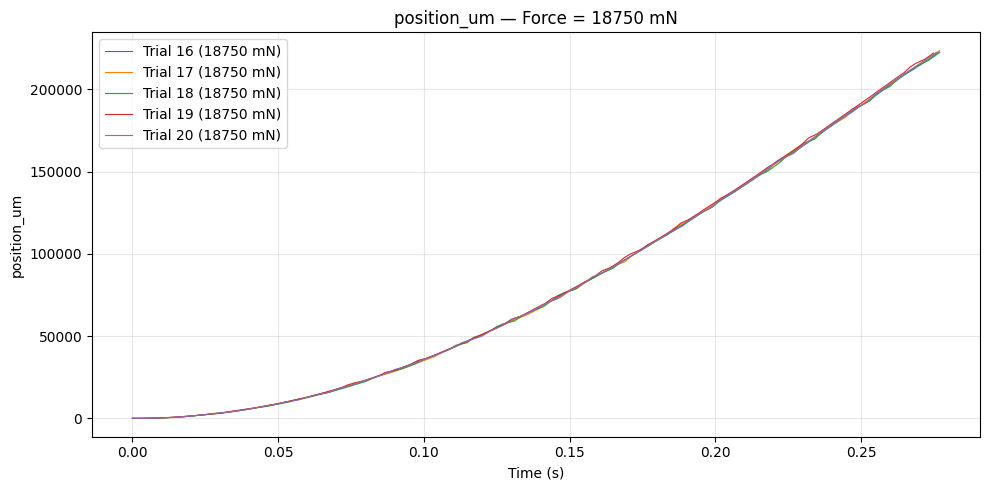

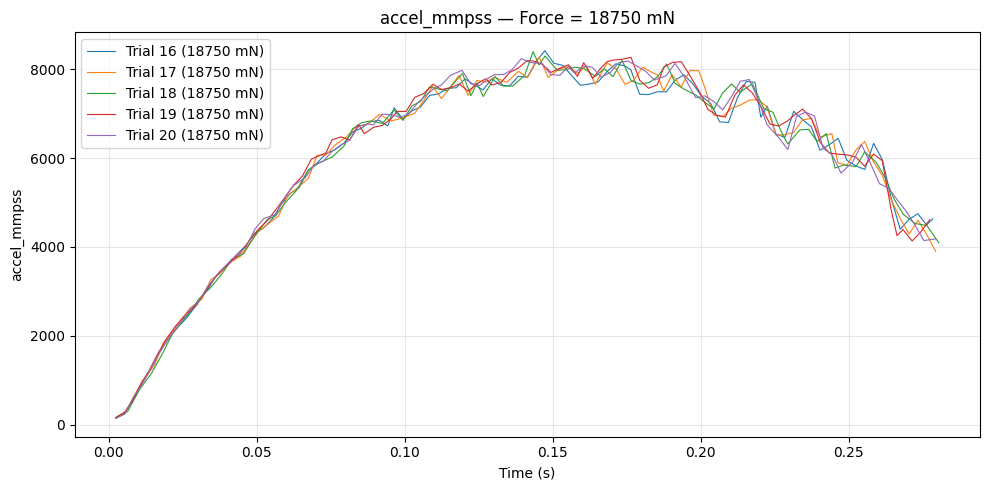

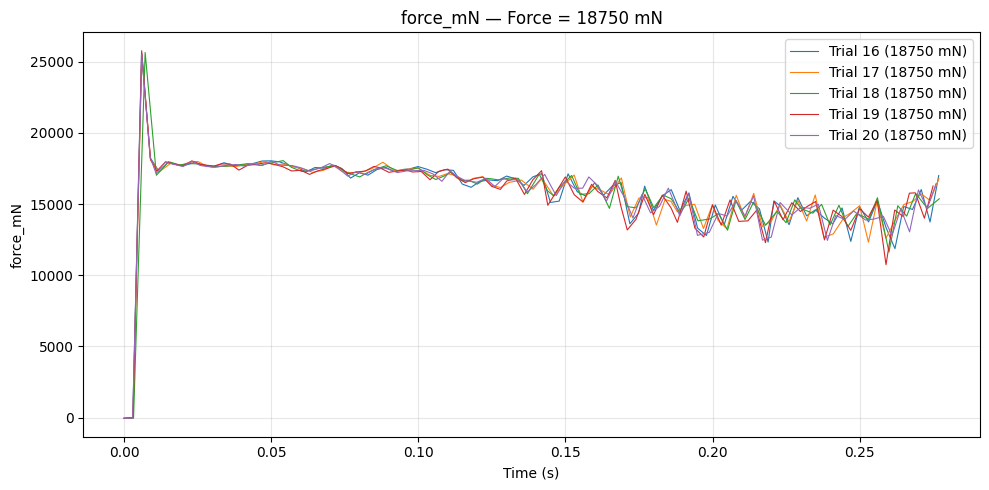

In [10]:
# ---------------------------------------------------------------------------
# Main — example usage
# ---------------------------------------------------------------------------

# 1) Single trial detail
trial_number = 16
command = 18750
# fig_single = plot_single_trial(trials[trial_number], title_suffix=f"(Trial {trial_number})")

# 2) Compare specific trials
# fig = plot_by_trial_numbers(trials, [1, 2, 3], field="position_um")
# fig = plot_by_trial_numbers(trials, [1, 2, 3], field="accel_mmpss")

# 3) All trials at a given force
_ = plot_by_force(index, trials, force_mN=command, field="position_um")
_ = plot_by_force(index, trials, force_mN=command, field="accel_mmpss")
_ = plot_by_force(index, trials, force_mN=command, field="force_mN")

# 4) Acceleration vs position
# _ = plot_accel_vs_position(trials, force_mN=12500)

# 5) Summary bar chart
# _ = plot_summary_stats(index, trials)

# Show all open figures
# plt.show()

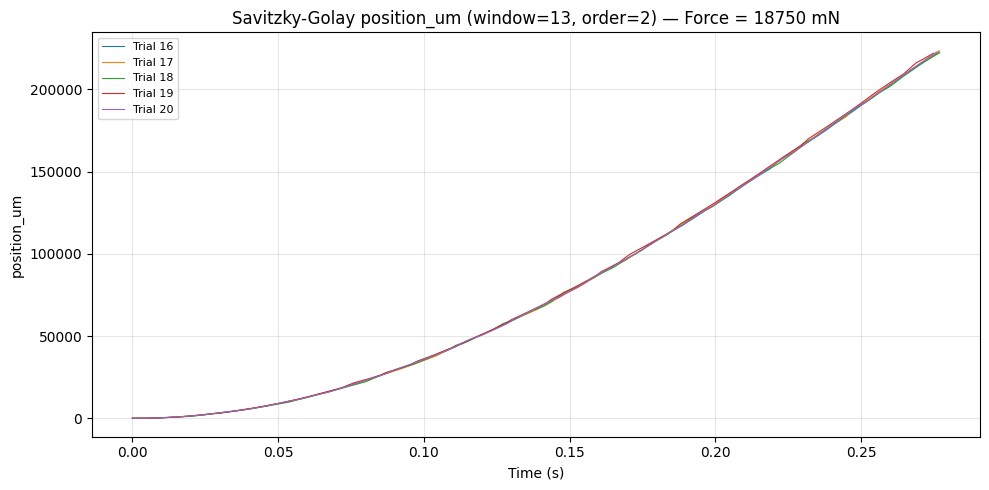

In [36]:
# Savitsky golay estimate of velocity #
# TODO: include savitsky golay estimate in friction record in the later block #
results, fig = plot_savgol_data(index, trials, force_mN=18750, field="position_um", window=13, order=2, derivative=0)

In [12]:
milli_conversion_factor = 1e-3 #not needed if both sensed forces and accelerations are milli

def plot_calc_mass(index, trials, force_command_mN, delta_x_um=10000):
    matching = index[index["force_commanded_mN"] == force_command_mN]
    trial_nums = matching["trial_num"].tolist()

    fig, ax = plt.subplots(figsize=(10, 5))
    results = {}

    for tnum in trial_nums:
        df = trials[tnum]
        times_raw = df["t_stream_s"].values
        position_um = df["position_um"].values.astype(np.float64)
        accel_raw_mmpss = df["accel_mmpss"].values.astype(np.float64)
        sensed_forces_mN = df["force_mN"].values.astype(np.float64)
        effective_mass_kg = sensed_forces_mN / accel_raw_mmpss

        ax.plot(times_raw, effective_mass_kg, linewidth=0.8, label=f"Trial {tnum}")
        results[tnum] = {'t':times_raw, 'mass_kg':effective_mass_kg}

    # --- Midpoint annotations (use first trial for reference position data) ---
    ref_df = trials[trial_nums[0]]
    ref_t = ref_df["t_stream_s"].values
    ref_pos = ref_df["position_um"].values.astype(np.float64)

    # Find time at which position is closest to MOTOR_CENTER_UM
    idx_center = np.argmin(np.abs(ref_pos - MOTOR_CENTER_UM))
    t_center = ref_t[idx_center]
    ax.axvline(t_center, color="k", linestyle="--", linewidth=1.2,
               label=f"Midpoint ({MOTOR_CENTER_UM:.0f} µm) at t = {t_center} s")

    # Highlight time range where position is within +/- delta_x of the midpoint
    in_range = np.abs(ref_pos - MOTOR_CENTER_UM) <= delta_x_um
    if np.any(in_range):
        t_lo = ref_t[in_range].min()
        t_hi = ref_t[in_range].max()
        ax.axvspan(t_lo, t_hi, alpha=0.15, color="gold",
                   label=f"±{delta_x_um} µm around midpoint")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mass (kg)")
    ax.set_ylim(0, 10)
    ax.set_title(f"Calculation of mass from F_sensed=m*a (force_command = {force_command_mN})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    print(f"Low time value for highlighted range: {t_lo}")
    print(f"High time value for highlighted range: {t_hi}")
    return results, fig

In [13]:
def mass_stats(effective_mass_kg, time_period_seconds=[0.25, -1]):
    """Get the mass statistics calculated from the same commanded force trials.
    If the end range is -1, then take samples from beginning of the range until the end of the time series"""
    min_time = time_period_seconds[0]
    max_time = time_period_seconds[1]

    estimated_masses_stats = {}
    all_mass_data = []
    
    for tnum in effective_mass_kg.keys():
        timepoints = effective_mass_kg[tnum]['t']
        mass_calculations = effective_mass_kg[tnum]['mass_kg']
        included_masses = []
        
        for t in range(len(timepoints)):
            m = mass_calculations[t]
            if timepoints[t] >= min_time:
                if max_time != -1:
                    if timepoints[t] <= max_time:
                        included_masses.append(m)
                        all_mass_data.append(m)
                else:
                    included_masses.append(m)
                    all_mass_data.append(m)
                    
        estimated_masses_stats[tnum] = {
                                        "mean": np.mean(included_masses),
                                        "std": np.std(included_masses),
                                        "max": np.max(included_masses),
                                        "min": np.min(included_masses),
                                        }
    estimated_masses_stats["over_all_trials"] = {
                                        "mean": np.mean(all_mass_data),
                                        "std": np.std(all_mass_data),
                                        "max": np.max(all_mass_data),
                                        "min": np.min(all_mass_data),
                                        }
    return estimated_masses_stats
                    

Low time value for highlighted range: 0.222729473374784
High time value for highlighted range: 0.24371779430657625


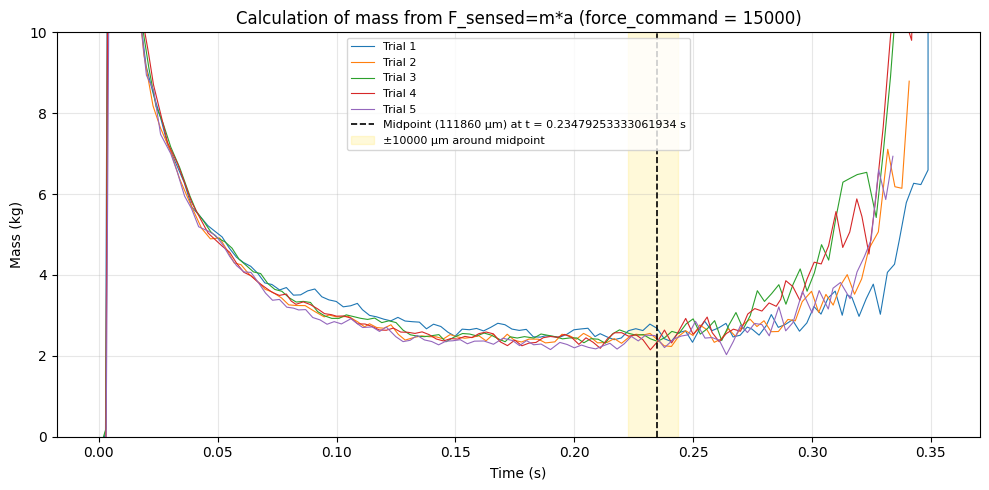

In [14]:
effective_mass_kg_15000, _ = plot_calc_mass(index, trials, force_command_mN=15000)

In [ ]:
effective_mass_kg_16250, _ = plot_calc_mass(index, trials, force_command_mN = 16250)

In [ ]:
effective_mass_kg_17500, _ = plot_calc_mass(index, trials, force_command_mN=17500)

In [ ]:
effective_mass_kg_18750, _ = plot_calc_mass(index, trials, force_command_mN=18750)

Calculate effective mass from the time period that's close to the middle of the shaft, which seems to be [0.20, 0.25] seconds (roughly)

Or calculate from the last 0.05 seconds of movement

In [ ]:
stats_15000 = mass_stats(effective_mass_kg_15000, time_period_seconds=[0.17, 0.20])
stats_16250 = mass_stats(effective_mass_kg_16250, time_period_seconds=[0.17, 0.20])
stats_17500 = mass_stats(effective_mass_kg_17500, time_period_seconds=[0.17, 0.20])
stats_18750 = mass_stats(effective_mass_kg_18750, time_period_seconds=[0.17, 0.20])

In [ ]:
stats_15000['over_all_trials']

In [ ]:
stats_16250['over_all_trials']

In [ ]:
stats_17500['over_all_trials']

In [ ]:
stats_18750['over_all_trials']

## Plots for Procedure 2

In [ ]:
print("Loading data...")
index2, trials2 = load_all_trials_v2()
print(f"Loaded {len(trials2)} trials2.")
print(index2.to_string(index=False))

In [ ]:
# Plot position, force, and acceleration vs time for all v2 trials
trial_nums_v2 = index2["trial_num"].tolist()
_ = plot_by_trial(trials2, trial_nums_v2, field="position_um")
_ = plot_by_trial(trials2, trial_nums_v2, field="force_mN")
_ = plot_by_trial(trials2, trial_nums_v2, field="accel_mmpss")

In [ ]:
# Calculate and plot effective mass for v2 trials
effective_mass_kg_v2, _ = plot_calc_mass_v2(index2, trials2)

In [ ]:
# Mass statistics for v2 trials
stats_v2 = mass_stats(effective_mass_kg_v2, time_period_seconds=[0.25, -1])
stats_v2

## Estimating Dynamic Friction from Procedure 1

**Known values:**
- Measured shaft mass: $m = 1.861$ kg
- Estimated max static friction: $F_{s} \approx 4750$–$5000$ mN

**Model:** During motion at constant commanded force:
$$F_{\text{commanded}} = m \cdot a + F_{\text{friction, dynamic}}$$

So:
$$F_{\text{friction, dynamic}} = F_{\text{commanded}} - m \cdot a$$

And the coefficient of dynamic (kinetic) friction (treating $mg$ as the normal force on the guides):
$$\mu_d = \frac{F_{\text{friction, dynamic}}}{m \cdot g}$$

In [39]:
# ---------------------------------------------------------------------------
# Known constants
# ---------------------------------------------------------------------------
M_SHAFT_KG = 1.861          # measured mass of the motor shaft (kg)
G_MMPSS = 9810.0            # gravitational acceleration in mm/s²
F_STATIC_LOW_MN = 4750.0    # lower bound of estimated static friction (mN)
F_STATIC_HIGH_MN = 5000.0   # upper bound of estimated static friction (mN)

# Force levels tested in Procedure 1
# FORCE_LEVELS_MN = [7500, 8750, 10000, 11250, 12500, 13750, 15000] #from 03/05/26
FORCE_LEVELS_MN = [15000, 16250, 17500, 18750] #from 03/06/26

In [50]:
# ---------------------------------------------------------------------------
# Compute F_friction_dynamic for each trial at each force level
# ---------------------------------------------------------------------------
# For each trial: F_friction = F_sensed - m * a
# We use the sensed force (force_mN) as F_commanded and accel_mmpss as a.
# Units: mN = kg * mm/s², so this is consistent.
#
# Because t_stream_s (for force_mN, position_um) and t_accel_s (for accel_mmpss)
# have slightly different timestamps, we interpolate acceleration onto the
# stream timestamps so all quantities share the same time base.
#
# Velocity is estimated by first smoothing positions with Savitzky-Golay,
# then taking finite differences with central averaging.

SAVGOL_WINDOW = 31
SAVGOL_ORDER = 2

friction_records = []

for force_mN in FORCE_LEVELS_MN:
    matching = index[index["force_commanded_mN"] == force_mN]
    for _, row in matching.iterrows():
        tnum = row["trial_num"]
        df = trials[tnum]

        t_stream = df["t_stream_s"].values.astype(np.float64)
        t_accel = df["t_accel_s"].values.astype(np.float64)
        sensed_force = df["force_mN"].values.astype(np.float64)
        accel_raw = df["accel_mmpss"].values.astype(np.float64)
        position_um = df["position_um"].values.astype(np.float64)

        # --- Interpolate acceleration onto the stream timestamps ---
        accel_interp_fn = interp1d(t_accel, accel_raw, kind="linear",
                                   bounds_error=False, fill_value="extrapolate")
        accel_at_stream = accel_interp_fn(t_stream)  # mm/s²

        # --- Estimate velocity from position (central differences) ---
        dt = np.diff(t_stream)
        vel_um_s = np.diff(position_um) / dt          # µm/s
        velocity_mm_s = np.empty_like(t_stream)
        velocity_mm_s[0] = vel_um_s[0] / 1000.0
        velocity_mm_s[-1] = vel_um_s[-1] / 1000.0
        velocity_mm_s[1:-1] = 0.5 * (vel_um_s[:-1] + vel_um_s[1:]) / 1000.0

        # --- Estimate velocity via Savitzky-Golay on position, then finite differences ---
        # position_mm_savgol = savgol_filter(position_um, window_length=SAVGOL_WINDOW,
        #                                    polyorder=SAVGOL_ORDER, deriv=0) / 1000.0
        # vel_mm_s_savgol = np.diff(position_mm_savgol) / dt
        # velocity_mm_s_savgol = np.empty_like(t_stream)
        # velocity_mm_s_savgol[0] = vel_mm_s_savgol[0]
        # velocity_mm_s_savgol[-1] = vel_mm_s_savgol[-1]
        # velocity_mm_s_savgol[1:-1] = 0.5 * (vel_mm_s_savgol[:-1] + vel_mm_s_savgol[1:])

        velocity_mm_s_savgol = savgol_filter(position_um, window_length=SAVGOL_WINDOW,
                                             polyorder=SAVGOL_ORDER, deriv=1, delta=np.mean(dt)) / 1000.0

        # --- F_friction = F_sensed - m * a  (all in mN) ---
        f_friction = sensed_force - M_SHAFT_KG * accel_at_stream

        friction_records.append({
            "trial_num": tnum,
            "force_commanded_mN": force_mN,
            "t": t_stream,
            "accel_mmpss": accel_at_stream,
            "sensed_force_mN": sensed_force,
            "f_friction_mN": f_friction,
            "velocity_mm_s": velocity_mm_s,
            "velocity_mm_s_savgol": velocity_mm_s_savgol,
        })

print(f"Computed friction for {len(friction_records)} trials across {len(FORCE_LEVELS_MN)} force levels.")

Computed friction for 20 trials across 4 force levels.


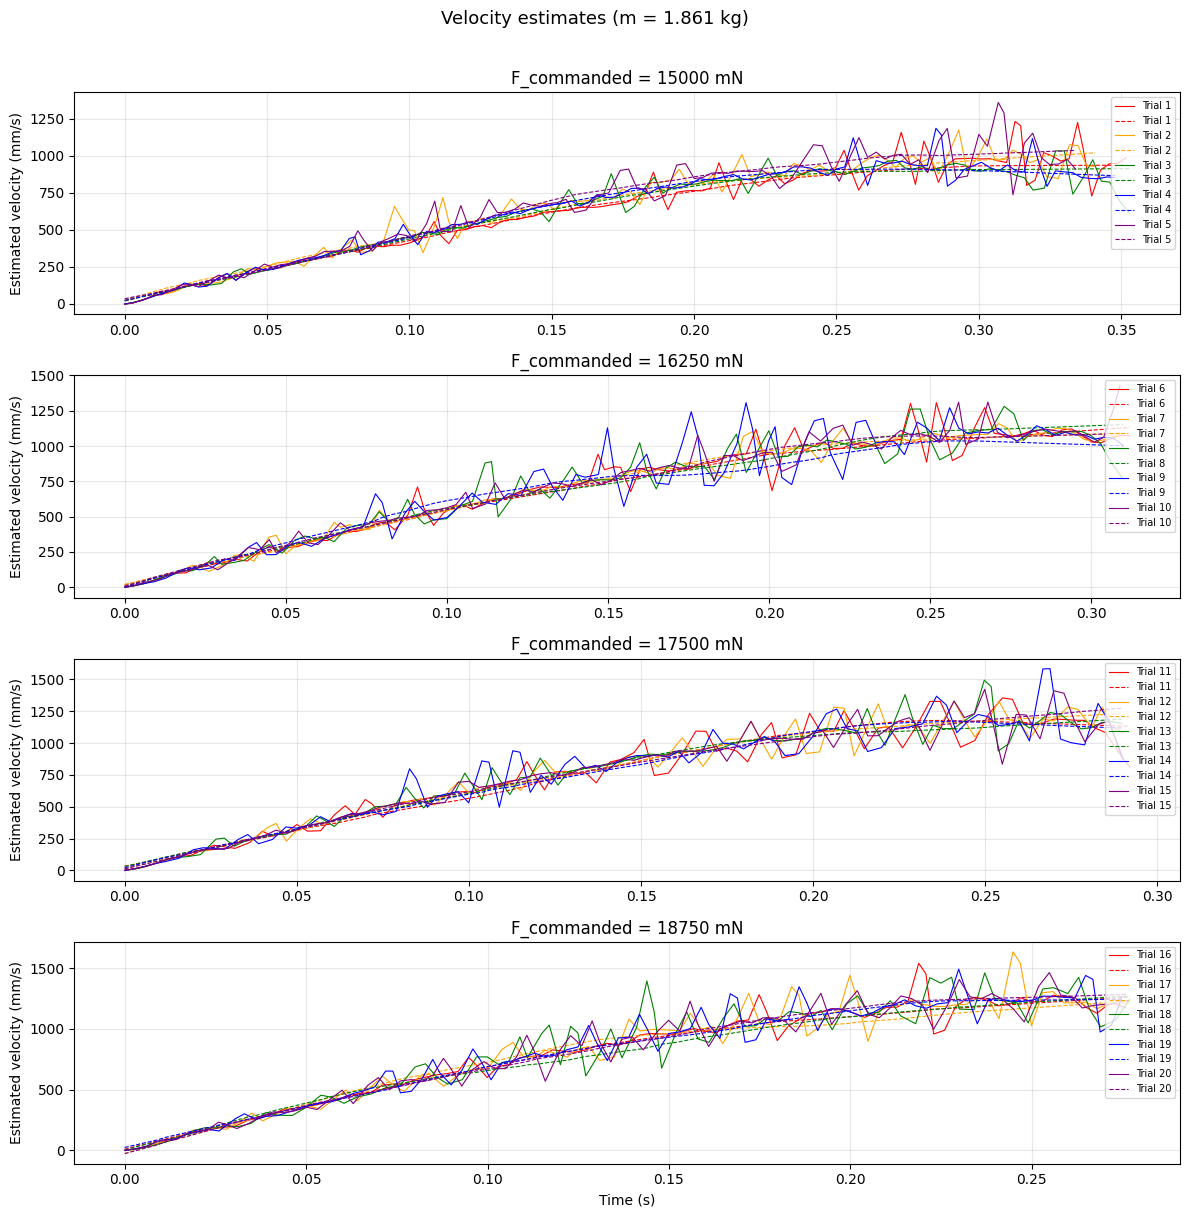

In [51]:
# ---------------------------------------------------------------------------
# Plot estimated velocity vs time for each force level
# ---------------------------------------------------------------------------
colors = ["red", "orange", "green", "blue", "purple"]
fig, axes = plt.subplots(len(FORCE_LEVELS_MN), 1, figsize=(12, 3 * len(FORCE_LEVELS_MN)), sharex=False)

for i, force_mN in enumerate(FORCE_LEVELS_MN):
    ax = axes[i]
    recs = [r for r in friction_records if r["force_commanded_mN"] == force_mN]
    for j, r in enumerate(recs):
        ax.plot(r["t"], r["velocity_mm_s"], linewidth=0.8, label=f"Trial {r['trial_num']}",
                 color=colors[j], linestyle="solid")
        ax.plot(r["t"], r["velocity_mm_s_savgol"], linewidth=0.8, label=f"Trial {r['trial_num']}",
                color=colors[j], linestyle="dashed")
    # ax.axhline(F_STATIC_LOW_MN, color="r", linestyle="--", alpha=0.5, label=f"F_static low ({F_STATIC_LOW_MN} mN)")
    # ax.axhline(F_STATIC_HIGH_MN, color="r", linestyle=":", alpha=0.5, label=f"F_static high ({F_STATIC_HIGH_MN} mN)")
    ax.set_ylabel("Estimated velocity (mm/s)")
    ax.set_title(f"F_commanded = {force_mN} mN")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"Velocity estimates (m = {M_SHAFT_KG} kg)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

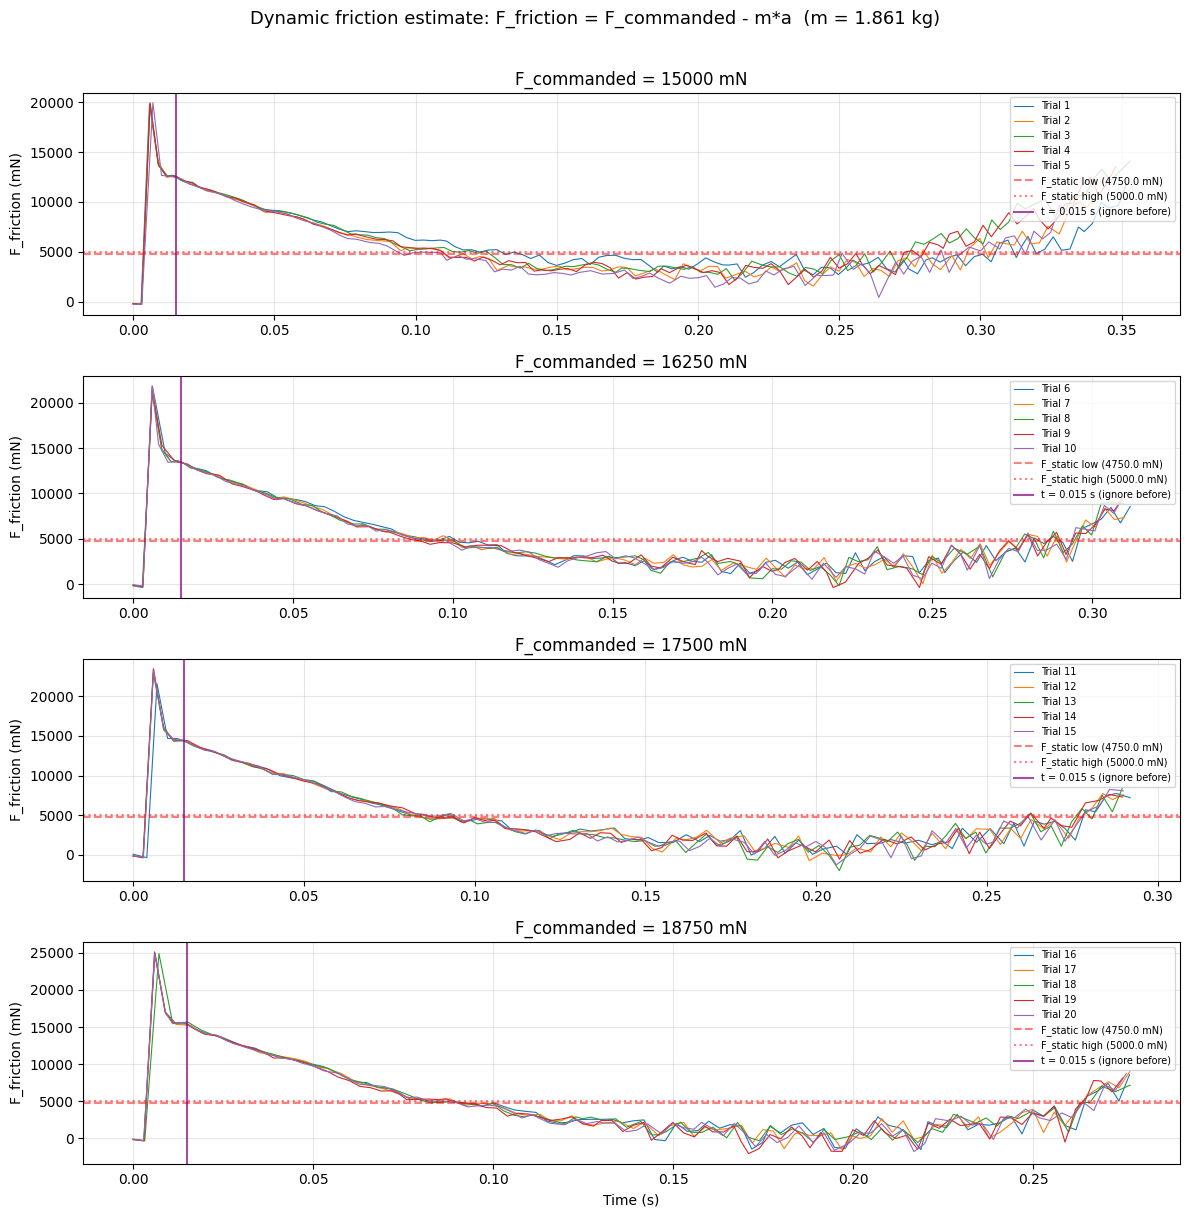

In [52]:
# ---------------------------------------------------------------------------
# Plot F_friction vs time for each force level
# ---------------------------------------------------------------------------
T_IGNORE_S = 0.015  # first 10 ms will be ignored in Stribeck estimates

fig, axes = plt.subplots(len(FORCE_LEVELS_MN), 1, figsize=(12, 3 * len(FORCE_LEVELS_MN)), sharex=False)

for i, force_mN in enumerate(FORCE_LEVELS_MN):
    ax = axes[i]
    recs = [r for r in friction_records if r["force_commanded_mN"] == force_mN]
    for r in recs:
        ax.plot(r["t"], r["f_friction_mN"], linewidth=0.8, label=f"Trial {r['trial_num']}")
    ax.axhline(F_STATIC_LOW_MN, color="r", linestyle="--", alpha=0.5, label=f"F_static low ({F_STATIC_LOW_MN} mN)")
    ax.axhline(F_STATIC_HIGH_MN, color="r", linestyle=":", alpha=0.5, label=f"F_static high ({F_STATIC_HIGH_MN} mN)")
    # Vertical line at t = 0.02 s to show the ignored region boundary
    ax.axvline(T_IGNORE_S, color="purple", linestyle="-", linewidth=1.5, alpha=0.7,
               label=f"t = {T_IGNORE_S} s (ignore before)")
    ax.set_ylabel("F_friction (mN)")
    ax.set_title(f"F_commanded = {force_mN} mN")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"Dynamic friction estimate: F_friction = F_commanded - m*a  (m = {M_SHAFT_KG} kg)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

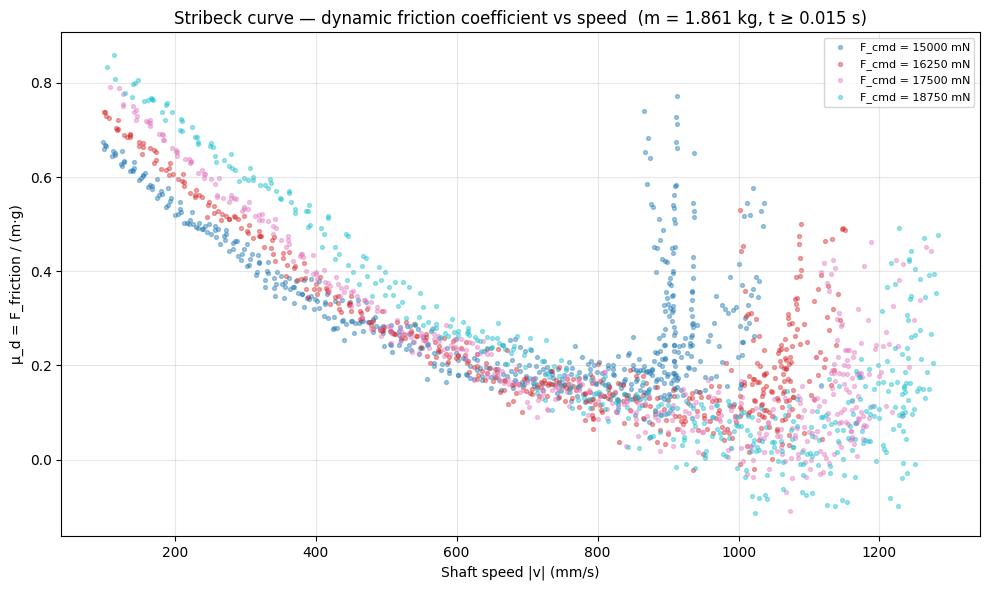

In [53]:
# ---------------------------------------------------------------------------
# Stribeck curve: shaft speed (mm/s) vs μ_d
# ---------------------------------------------------------------------------
# Uses data from t >= T_IGNORE_S (0.02 s) to exclude the static-friction
# breakaway transient. μ_d = F_friction / (m * g) at each sample.

weight_mN_stribeck = M_SHAFT_KG * G_MMPSS  # normal force in mN

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(FORCE_LEVELS_MN)))

for i, force_mN in enumerate(FORCE_LEVELS_MN):
    recs = [r for r in friction_records if r["force_commanded_mN"] == force_mN]
    speeds_all = []
    mu_d_all = []
    for r in recs:
        mask = r["t"] >= T_IGNORE_S
        speed = np.abs(r["velocity_mm_s_savgol"][mask])      # absolute speed (mm/s)
        mu_d = r["f_friction_mN"][mask] / weight_mN_stribeck
        speeds_all.extend(speed.tolist())
        mu_d_all.extend(mu_d.tolist())

    ax.scatter(speeds_all, mu_d_all, s=8, alpha=0.4, color=colors[i],
               label=f"F_cmd = {force_mN} mN")

ax.set_xlabel("Shaft speed |v| (mm/s)")
ax.set_ylabel("μ_d = F_friction / (m·g)")
ax.set_title(f"Stribeck curve — dynamic friction coefficient vs speed  (m = {M_SHAFT_KG} kg, t ≥ {T_IGNORE_S} s)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# ---------------------------------------------------------------------------
# Summary statistics: mean dynamic friction per force level
# ---------------------------------------------------------------------------
# Exclude early samples (t < 0.05 s) to avoid startup transients where
# the shaft may still be breaking free from static friction.

T_MIN_S = 0.05  # skip early transient

summary_rows = []

for force_mN in FORCE_LEVELS_MN:
    recs = [r for r in friction_records if r["force_commanded_mN"] == force_mN]
    all_friction_values = []
    for r in recs:
        mask = r["t"] >= T_MIN_S
        all_friction_values.extend(r["f_friction_mN"][mask].tolist())
    
    arr = np.array(all_friction_values)
    summary_rows.append({
        "F_commanded (mN)": force_mN,
        "mean F_friction (mN)": np.mean(arr),
        "std F_friction (mN)": np.std(arr),
        "median F_friction (mN)": np.median(arr),
        "n_samples": len(arr),
    })

friction_summary = pd.DataFrame(summary_rows)
print(friction_summary.to_string(index=False))

 F_commanded (mN)  mean F_friction (mN)  std F_friction (mN)  median F_friction (mN)  n_samples
            15000           5027.400306          2321.657109             4408.951677        490
            16250           3747.627150          2119.926495             3105.596302        426
            17500           3224.107210          2315.845851             2714.807861        387
            18750           2903.416135          2620.880531             2325.584543        377


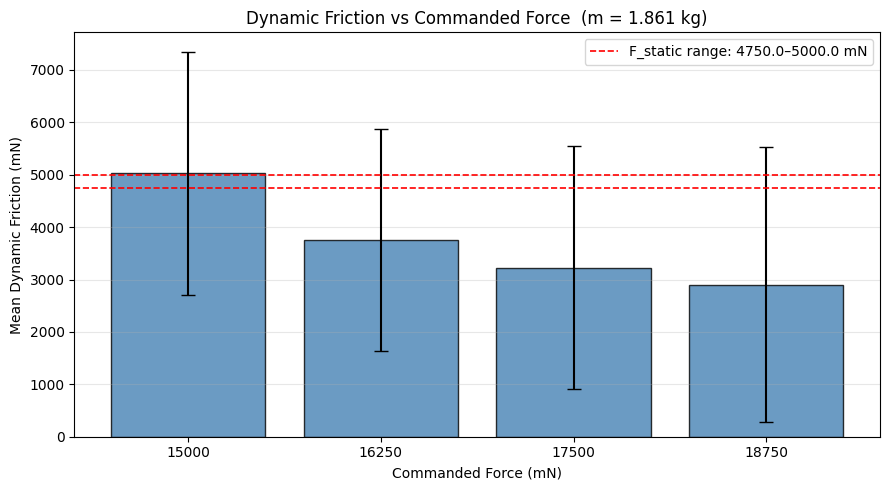

In [55]:
# ---------------------------------------------------------------------------
# Plot: mean dynamic friction vs commanded force (bar chart with error bars)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

forces = friction_summary["F_commanded (mN)"].values
means = friction_summary["mean F_friction (mN)"].values
stds = friction_summary["std F_friction (mN)"].values

ax.bar(forces.astype(str), means, yerr=stds, capsize=5,
       color="steelblue", edgecolor="black", alpha=0.8)
ax.axhline(F_STATIC_LOW_MN, color="r", linestyle="--", linewidth=1.2,
           label=f"F_static range: {F_STATIC_LOW_MN}–{F_STATIC_HIGH_MN} mN")
ax.axhline(F_STATIC_HIGH_MN, color="r", linestyle="--", linewidth=1.2)

ax.set_xlabel("Commanded Force (mN)")
ax.set_ylabel("Mean Dynamic Friction (mN)")
ax.set_title(f"Dynamic Friction vs Commanded Force  (m = {M_SHAFT_KG} kg)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Estimate coefficient of dynamic friction: μ_d = F_friction / (m * g)
# ---------------------------------------------------------------------------
# Here m*g is the weight of the shaft acting as the normal force on the guides.
# m*g in mN: M_SHAFT_KG * G_MMPSS = 1.861 * 9810 = 18256.41 mN

weight_mN = M_SHAFT_KG * G_MMPSS
print(f"Shaft weight (normal force): {weight_mN:.1f} mN")

# Per force level
friction_summary["μ_d"] = friction_summary["mean F_friction (mN)"] / weight_mN
friction_summary["μ_d_std"] = friction_summary["std F_friction (mN)"] / weight_mN
print("\n", friction_summary[["F_commanded (mN)", "mean F_friction (mN)", "μ_d", "μ_d_std"]].to_string(index=False))

# Overall estimate (pooling all force levels)
all_friction_pooled = []
for force_mN in FORCE_LEVELS_MN:
    recs = [r for r in friction_records if r["force_commanded_mN"] == force_mN]
    for r in recs:
        mask = r["t"] >= T_MIN_S
        all_friction_pooled.extend(r["f_friction_mN"][mask].tolist())

all_friction_pooled = np.array(all_friction_pooled)
mu_d_overall = np.mean(all_friction_pooled) / weight_mN
mu_d_overall_std = np.std(all_friction_pooled) / weight_mN

print(f"\n--- Overall dynamic friction estimate (all force levels pooled) ---")
print(f"  F_friction_dynamic = {np.mean(all_friction_pooled):.1f} ± {np.std(all_friction_pooled):.1f} mN")
print(f"  μ_d = {mu_d_overall:.4f} ± {mu_d_overall_std:.4f}")
print(f"\n--- For comparison ---")
print(f"  F_static ≈ {F_STATIC_LOW_MN}–{F_STATIC_HIGH_MN} mN")
print(f"  μ_s ≈ {F_STATIC_LOW_MN/weight_mN:.4f}–{F_STATIC_HIGH_MN/weight_mN:.4f}")

In [ ]:
# ---------------------------------------------------------------------------
# Plot: μ_d per force level
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(forces.astype(str), friction_summary["μ_d"].values,
       yerr=friction_summary["μ_d_std"].values, capsize=5,
       color="coral", edgecolor="black", alpha=0.8)
ax.axhline(mu_d_overall, color="navy", linestyle="-", linewidth=1.5,
           label=f"Overall μ_d = {mu_d_overall:.4f}")
ax.axhline(F_STATIC_LOW_MN / weight_mN, color="r", linestyle="--", linewidth=1.2,
           label=f"μ_s range: {F_STATIC_LOW_MN/weight_mN:.4f}–{F_STATIC_HIGH_MN/weight_mN:.4f}")
ax.axhline(F_STATIC_HIGH_MN / weight_mN, color="r", linestyle="--", linewidth=1.2)

ax.set_xlabel("Commanded Force (mN)")
ax.set_ylabel("μ_d (dimensionless)")
ax.set_title(f"Coefficient of Dynamic Friction per Force Level  (m = {M_SHAFT_KG} kg)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()